In [222]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score
)

In [223]:
data = pd.read_csv("train_dataset_final1.csv")
data.head()
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25247 entries, 0 to 25246
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         25247 non-null  int64  
 1   marriage            25247 non-null  int64  
 2   sex                 25247 non-null  int64  
 3   education           25247 non-null  int64  
 4   LIMIT_BAL           25247 non-null  int64  
 5   age                 25121 non-null  float64
 6   pay_0               25247 non-null  int64  
 7   pay_2               25247 non-null  int64  
 8   pay_3               25247 non-null  int64  
 9   pay_4               25247 non-null  int64  
 10  pay_5               25247 non-null  int64  
 11  pay_6               25247 non-null  int64  
 12  Bill_amt1           25247 non-null  float64
 13  Bill_amt2           25247 non-null  float64
 14  Bill_amt3           25247 non-null  float64
 15  Bill_amt4           25247 non-null  float64
 16  Bill

Customer_ID             0
marriage                0
sex                     0
education               0
LIMIT_BAL               0
age                   126
pay_0                   0
pay_2                   0
pay_3                   0
pay_4                   0
pay_5                   0
pay_6                   0
Bill_amt1               0
Bill_amt2               0
Bill_amt3               0
Bill_amt4               0
Bill_amt5               0
Bill_amt6               0
pay_amt1                0
pay_amt2                0
pay_amt3                0
pay_amt4                0
pay_amt5                0
pay_amt6                0
AVG_Bill_amt            0
PAY_TO_BILL_ratio       0
next_month_default      0
dtype: int64

In [224]:

data.drop('Customer_ID', axis=1, inplace=True)
data.head()

,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
0,2,0,2,60000,25.0,2,2,2,0,0,...,20750.63,2000.21,0.00,1134.85,1821.78,1500.03,1500.24,41511.50,0.03,0
1,2,1,1,290000,24.0,0,0,-2,-2,-1,...,1350.30,0.00,0.17,0.00,2700.10,0.00,1349.72,2534.50,0.27,0
2,1,0,2,180000,63.0,0,0,0,0,0,...,52991.51,2086.94,2199.99,1845.66,2000.35,1923.00,1999.78,50422.00,0.04,0
3,1,1,2,210000,43.0,0,0,0,0,0,...,76945.47,3348.07,3380.91,3400.45,2683.97,2744.00,2892.10,86229.50,0.04,0
4,2,0,1,280000,32.0,-2,-2,-2,-2,-2,...,1.35,999.78,3186.27,45027.78,2100.09,0.01,0.27,11814.33,0.72,0


In [225]:
dp = data.duplicated().sum()
print(dp)
data = data.drop_duplicates()
dp = data.duplicated().sum()
print(dp)

803
0


In [226]:
print(data['age'].isnull().sum()) 
data = data.dropna(subset=['age']) #dropping missing values of ages because missing count is too small infront of train data
print(data['age'].isnull().sum()) 

126
0


next_month_default
0    19534
1     4784
Name: count, dtype: int64


([<matplotlib.patches.Wedge at 0x15909acdb80>,
 [Text(-0.896520421949817, 0.6373783280179225, 'Non-Default'),
  Text(0.8965204816254785, -0.6373782440796204, 'Defaulter')])

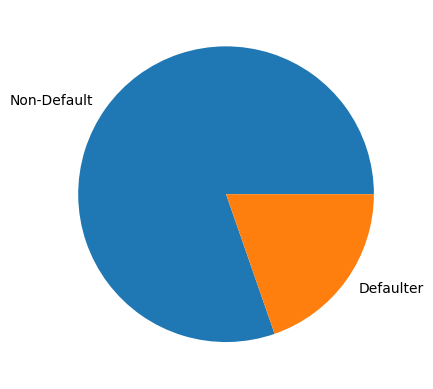

In [227]:
size = data['next_month_default'].value_counts()
print(size)
label = ["Non-Default","Defaulter" ]
plt.pie(size,labels=label)

# the data is quite imbalance.

In [228]:
counts_before = data['education'].value_counts()
print(counts_before)
data['education'] = data['education'].apply(lambda x:x if x<= 4 else 4).astype(int)
counts = data['education'].value_counts()
print(counts)


education
2    11284
1     8659
3     3963
5      246
4      111
6       41
0       14
Name: count, dtype: int64
education
2    11284
1     8659
3     3963
4      398
0       14
Name: count, dtype: int64


In [229]:
counts_before = data['marriage'].value_counts()
print(counts_before)
data['marriage'] = data['marriage'].apply(lambda x:x if x >0  else 3).astype(int)
counts = data['marriage'].value_counts()
print(counts)

marriage
2    12924
1    11081
3      263
0       50
Name: count, dtype: int64
marriage
2    12924
1    11081
3      313
Name: count, dtype: int64


In [230]:
data.head().T

,0,1,2,3,4
marriage,2.00,2.00,1.00,1.00,2.00
sex,0.00,1.00,0.00,1.00,0.00
education,2.00,1.00,2.00,2.00,1.00
LIMIT_BAL,60000.00,290000.00,180000.00,210000.00,280000.00
age,25.00,24.00,63.00,43.00,32.00
pay_0,2.00,0.00,0.00,0.00,-2.00
pay_2,2.00,0.00,0.00,0.00,-2.00
pay_3,2.00,-2.00,0.00,0.00,-2.00
pay_4,0.00,-2.00,0.00,0.00,-2.00
pay_5,0.00,-1.00,0.00,0.00,-2.00


In [231]:
data = pd.get_dummies(data, columns=['sex', 'marriage', 'education'], 
                      prefix=['sex', 'marriage', 'education'], 
                      drop_first=True)
data.head()

,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,Bill_amt1,Bill_amt2,...,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default,sex_1,marriage_2,marriage_3,education_1,education_2,education_3,education_4
0,60000,25.0,2,2,2,0,0,0,60323.86,60728.22,...,41511.50,0.03,0,False,True,False,False,True,False,False
1,290000,24.0,0,0,-2,-2,-1,0,11157.67,0.00,...,2534.50,0.27,0,True,True,False,True,False,False,False
2,180000,63.0,0,0,0,0,0,0,47930.96,48921.91,...,50422.00,0.04,0,False,False,False,False,True,False,False
3,210000,43.0,0,0,0,0,0,0,91152.44,92916.01,...,86229.50,0.04,0,True,False,False,False,True,False,False
4,280000,32.0,-2,-2,-2,-2,-2,-2,19666.40,999.04,...,11814.33,0.72,0,False,True,False,True,False,False,False


1135


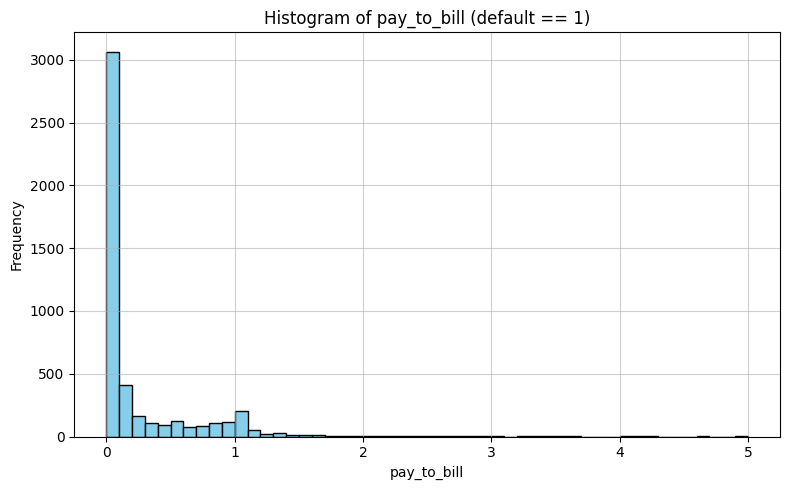

In [232]:
bins = np.arange(0, 5.1, 0.1) 
default_data = data[data['next_month_default'] == 1]

count = (default_data['PAY_TO_BILL_ratio'] >= 0.3).sum()
print(count)
plt.figure(figsize=(8, 5))
plt.hist(default_data['PAY_TO_BILL_ratio'], bins=bins, edgecolor='black', color='skyblue')

plt.title('Histogram of pay_to_bill (default == 1)')
plt.xlabel('pay_to_bill')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

1959


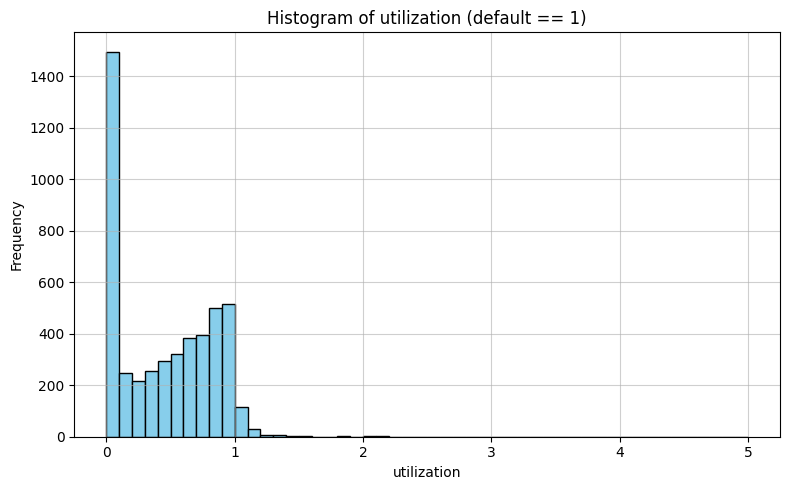

In [ ]:
data['utilization'] = (data['Bill_amt1'] + data['Bill_amt2'] + data['Bill_amt3'] + data['Bill_amt4'] + data['Bill_amt5'] + data['Bill_amt6'])/(data['LIMIT_BAL']*6)


bins = np.arange(0, 5.1, 0.1) 

default_data = data[data['next_month_default'] == 1]

count = (default_data['utilization'] < 0.3).sum()
print(count)
plt.figure(figsize=(8, 5))
plt.hist(default_data['utilization'], bins=bins, edgecolor='black', color='skyblue')

plt.title('Histogram of utilization (default == 1)')
plt.xlabel('utilization')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()


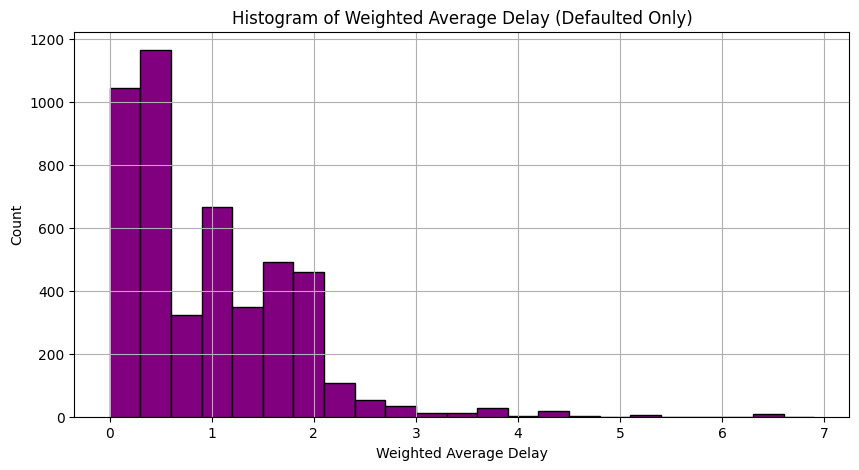

In [234]:
weights = {'pay_0': 6, 'pay_2': 5, 'pay_3': 4, 'pay_4': 3, 'pay_5': 2, 'pay_6' : 1}
columns = list(weights.keys())

transformed = data[columns].copy()

for col in columns:
    transformed[col] = transformed[col].apply(lambda x: 0 if x < 0 else 0.5 if x == 0 else x)

for col in columns:
    transformed[col] *= weights[col]

total_weight = sum(weights.values())
data['weighted_avg_delay'] = transformed.sum(axis=1) / total_weight

defaulted = data[data['next_month_default'] == 1]

bins = np.arange(0, 7.1, 0.3)

plt.figure(figsize=(10, 5))
plt.hist(defaulted['weighted_avg_delay'], bins=bins, color='purple', edgecolor='black')
plt.title('Histogram of Weighted Average Delay (Defaulted Only)')
plt.xlabel('Weighted Average Delay')
plt.ylabel('Count')
plt.grid(True)
plt.show()



In [235]:
data.drop('Bill_amt3', axis=1, inplace=True)
data.drop('Bill_amt4', axis=1, inplace=True)
data.drop('Bill_amt5', axis=1, inplace=True)
data.drop('Bill_amt6', axis=1, inplace=True)


data.drop('AVG_Bill_amt', axis=1, inplace=True)

data.drop('pay_3', axis=1, inplace=True)
data.drop('pay_4', axis=1, inplace=True)
data.drop('pay_5', axis=1, inplace=True)
data.drop('pay_6', axis=1, inplace=True)

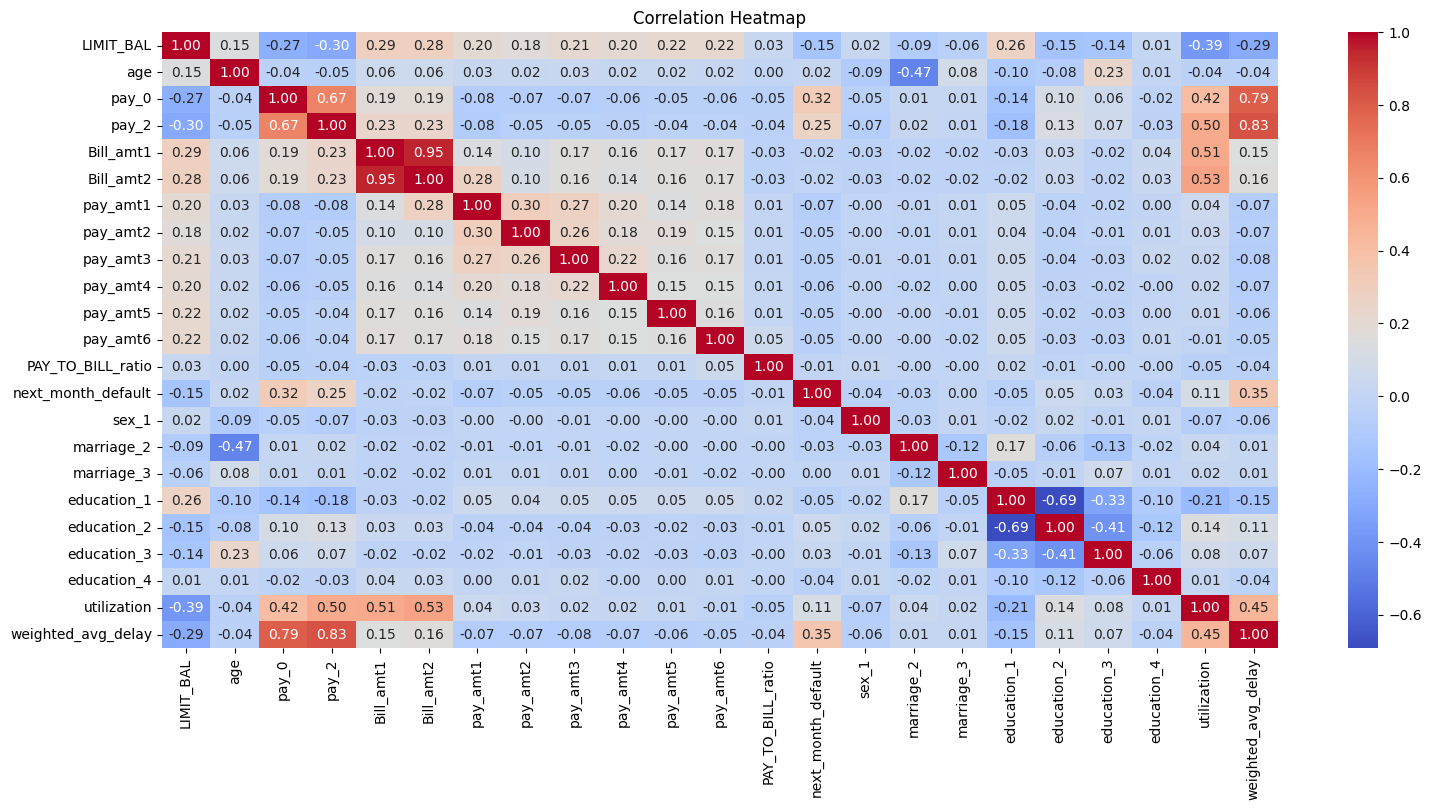

In [236]:
correlation_mat = data.corr()
plt.figure(figsize=(18,8))  
sns.heatmap(correlation_mat,fmt='.2f',annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [237]:

target_col = 'next_month_default'  

X = data.drop(columns=[target_col])
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(y_train.value_counts())
print(y_test.value_counts())


next_month_default
0    14650
1     3588
Name: count, dtype: int64
next_month_default
0    4884
1    1196
Name: count, dtype: int64


In [238]:
smote = SMOTE(random_state=42)
X_train_sampled , y_train_sampled = smote.fit_resample(X_train, y_train)

In [239]:
X_train_sampled.head()

,LIMIT_BAL,age,pay_0,pay_2,Bill_amt1,Bill_amt2,pay_amt1,pay_amt2,pay_amt3,pay_amt4,...,PAY_TO_BILL_ratio,sex_1,marriage_2,marriage_3,education_1,education_2,education_3,education_4,utilization,weighted_avg_delay
0,50000,55.0,-1,-1,1100.27,0.36,0.13,0.12,0.00,0.03,...,0.00,True,False,False,False,True,False,False,0.003671,0.000000
1,220000,37.0,0,0,81190.16,78537.80,2999.78,2999.74,3520.03,3000.06,...,0.24,True,False,False,False,True,False,False,0.398006,0.500000
2,100000,24.0,0,0,7093.50,8249.48,1438.68,1999.62,10070.13,1001.97,...,0.37,True,True,False,False,True,False,False,0.072481,0.452381
3,90000,23.0,0,0,87727.39,89403.20,3160.40,3687.94,4558.71,1665.28,...,0.04,True,True,False,False,True,False,False,0.835911,0.500000
4,260000,36.0,0,0,200592.06,206177.58,8500.35,6999.77,7507.87,7499.91,...,0.04,True,False,False,False,True,False,False,0.809186,0.500000


In [240]:
y_train_sampled.value_counts()


next_month_default
0    14650
1    14650
Name: count, dtype: int64

In [ ]:
models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=10, min_samples_split=2, criterion='gini', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, reg_lambda=1, use_label_encoder=False, eval_metric='logloss', random_state=42,max_depth = 3),
    "LightGBM": LGBMClassifier(n_estimators=100, boosting_type='dart', random_state=42,objective = 'binary',max_depth= -1 ),
    "Logistic": LogisticRegression(C=0.01, solver='liblinear', penalty='l2', random_state=42 , max_iter=10000),
    "AdaBoost" : AdaBoostClassifier(n_estimators=200,learning_rate=0.1,random_state=42),
    "Support Vector Machine" : SVC(C=0.1 , gamma='scale',kernel='rbf',probability=True,random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_sampled, y_train_sampled)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    best_f2 = 0
    best_metrics = {}
    best_thresh = 0
    
    for thresh in np.arange(0.1, 0.51, 0.01):
        y_pred = (y_proba >= thresh).astype(int)
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        f2 = fbeta_score(y_test, y_pred, beta=2)
        auc = roc_auc_score(y_test, y_proba)
        
        if f2 > best_f2:
            best_f2 = f2
            best_thresh = thresh
            best_metrics = {
                "Model": name,
                "Best_Threshold": round(thresh, 2),
                "Accuracy": round(acc, 4),
                "Precision": round(prec, 4),
                "Recall": round(rec, 4),
                "F1": round(f1, 4),
                "F2": round(f2, 4),
                "ROC_AUC": round(auc, 4)
            }
    
    results.append(best_metrics)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

In [242]:
# below this block i have written code to predict the validation data set.

In [243]:
validation_data = pd.read_csv("validate_dataset_final.csv")
result_final = validation_data[['Customer_ID']].copy()

validation_data.drop('Customer_ID', axis=1, inplace=True)
validation_data.head()

,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,Bill_amt5,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio
0,1,1,2,220000,32,0,0,0,0,0,...,17831.13,15670.47,2000.03,3999.90,1419.80,1999.97,3000.21,30788.71,23456.33,0.31
1,2,0,1,350000,35,-1,-1,-1,0,0,...,10832.78,2261.45,33891.01,16267.19,4026.80,234.10,1565.11,26346.39,13660.33,1.00
2,2,1,1,310000,39,0,0,0,0,0,...,240520.57,246524.45,11026.94,10499.83,14000.32,10000.12,10000.16,10000.21,258034.17,0.04
3,1,0,2,20000,47,0,0,0,2,2,...,15040.17,14749.97,1200.00,2799.83,0.14,1499.93,0.02,1000.26,13333.33,0.08
4,2,1,2,500000,30,0,0,0,0,0,...,69054.15,64841.30,25463.94,43095.31,7521.96,9065.17,8841.07,12000.21,77204.50,0.23


In [244]:
validation_data['education'] = validation_data['education'].apply(lambda x:x if x<= 4 else 4).astype(int)
counts = validation_data['education'].value_counts()
print(counts)

education
2    2374
1    1796
3     760
4      84
0       2
Name: count, dtype: int64


In [245]:
validation_data['marriage'] = validation_data['marriage'].apply(lambda x:x if x >0  else 3).astype(int)
counts = validation_data['marriage'].value_counts()
print(counts)

marriage
2    2702
1    2262
3      52
Name: count, dtype: int64


In [246]:
validation_data = pd.get_dummies(validation_data, columns=['sex', 'marriage', 'education'], 
                      prefix=['sex', 'marriage', 'education'], 
                      drop_first=True)

validation_data.head()

,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,Bill_amt1,Bill_amt2,...,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,sex_1,marriage_2,marriage_3,education_1,education_2,education_3,education_4
0,220000,32,0,0,0,0,0,0,28853.10,29144.77,...,30788.71,23456.33,0.31,True,False,False,False,True,False,False
1,350000,35,-1,-1,-1,0,0,0,4438.78,33718.18,...,26346.39,13660.33,1.00,False,True,False,True,False,False,False
2,310000,39,0,0,0,0,0,0,300500.53,265766.60,...,10000.21,258034.17,0.04,True,True,False,True,False,False,False
3,20000,47,0,0,0,2,2,2,10628.45,11650.67,...,1000.26,13333.33,0.08,False,False,False,False,True,False,False
4,500000,30,0,0,0,0,0,0,98617.77,73464.07,...,12000.21,77204.50,0.23,True,True,False,False,True,False,False


In [247]:
validation_data['utilization'] = (validation_data['Bill_amt1'] + validation_data['Bill_amt2'] + validation_data['Bill_amt3'] + validation_data['Bill_amt4'] + validation_data['Bill_amt5'] + validation_data['Bill_amt6'])/(validation_data['LIMIT_BAL']*6)


In [248]:
weights = {'pay_0': 6, 'pay_2': 5, 'pay_3': 4, 'pay_4': 3, 'pay_5': 2, 'pay_6' : 1}
columns = list(weights.keys())

transformed = validation_data[columns].copy()

for col in columns:
    transformed[col] = transformed[col].apply(lambda x: 0 if x < 0 else 0.5 if x == 0 else x)

for col in columns:
    transformed[col] *= weights[col]

total_weight = sum(weights.values())
validation_data['weighted_avg_delay'] = transformed.sum(axis=1) / total_weight

In [249]:
validation_data.drop('Bill_amt3', axis=1, inplace=True)
validation_data.drop('Bill_amt4', axis=1, inplace=True)
validation_data.drop('Bill_amt5', axis=1, inplace=True)
validation_data.drop('Bill_amt6', axis=1, inplace=True)

validation_data.drop('AVG_Bill_amt', axis=1, inplace=True)

validation_data.drop('pay_3', axis=1, inplace=True)
validation_data.drop('pay_4', axis=1, inplace=True)
validation_data.drop('pay_5', axis=1, inplace=True)
validation_data.drop('pay_6', axis=1, inplace=True)

In [250]:
data.head()

,LIMIT_BAL,age,pay_0,pay_2,Bill_amt1,Bill_amt2,pay_amt1,pay_amt2,pay_amt3,pay_amt4,...,next_month_default,sex_1,marriage_2,marriage_3,education_1,education_2,education_3,education_4,utilization,weighted_avg_delay
0,60000,25.0,2,2,60323.86,60728.22,2000.21,0.00,1134.85,1821.78,...,0,False,True,False,False,True,False,False,0.691858,1.571429
1,290000,24.0,0,0,11157.67,0.00,0.00,0.17,0.00,2700.10,...,0,True,True,False,True,False,False,False,0.008742,0.285714
2,180000,63.0,0,0,47930.96,48921.91,2086.94,2199.99,1845.66,2000.35,...,0,False,False,False,False,True,False,False,0.280120,0.500000
3,210000,43.0,0,0,91152.44,92916.01,3348.07,3380.91,3400.45,2683.97,...,0,True,False,False,False,True,False,False,0.410618,0.500000
4,280000,32.0,-2,-2,19666.40,999.04,999.78,3186.27,45027.78,2100.09,...,0,False,True,False,True,False,False,False,0.042194,0.000000


In [251]:
validation_data.head()

,LIMIT_BAL,age,pay_0,pay_2,Bill_amt1,Bill_amt2,pay_amt1,pay_amt2,pay_amt3,pay_amt4,...,PAY_TO_BILL_ratio,sex_1,marriage_2,marriage_3,education_1,education_2,education_3,education_4,utilization,weighted_avg_delay
0,220000,32,0,0,28853.10,29144.77,2000.03,3999.90,1419.80,1999.97,...,0.31,True,False,False,False,True,False,False,0.106620,0.500000
1,350000,35,-1,-1,4438.78,33718.18,33891.01,16267.19,4026.80,234.10,...,1.00,False,True,False,True,False,False,False,0.039029,0.142857
2,310000,39,0,0,300500.53,265766.60,11026.94,10499.83,14000.32,10000.12,...,0.04,True,True,False,True,False,False,False,0.832369,0.500000
3,20000,47,0,0,10628.45,11650.67,1200.00,2799.83,0.14,1499.93,...,0.08,False,False,False,False,True,False,False,0.666662,0.928571
4,500000,30,0,0,98617.77,73464.07,25463.94,43095.31,7521.96,9065.17,...,0.23,True,True,False,False,True,False,False,0.154409,0.500000


In [252]:
target_col = 'next_month_default'  

X_ = data.drop(columns=[target_col])
y_ = data[target_col]

In [253]:
smote = SMOTE(random_state=42)
X_train_sampled_ , y_train_sampled_ = smote.fit_resample(X_, y_)


In [254]:
model = LGBMClassifier(n_estimators=100, boosting_type='dart', random_state=42,objective = 'binary',max_depth= -1 )
model.fit(X_train_sampled_,y_train_sampled_)

prediction_proba = model.predict_proba(validation_data)[:, 1]

threshold = 0.20
predictions = (prediction_proba >= threshold).astype(int)

[LightGBM] [Info] Number of positive: 19534, number of negative: 19534
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006309 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3341
[LightGBM] [Info] Number of data points in the train set: 39068, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [255]:
result_final['next_month_default'] = predictions
result_final.to_csv('submission_23115082.csv', index=False)
